# Media Framing of Palestine – Progress Report

**Course:** CS 418 - Introduction to Data Science  
**Group:** 404 Data Not Found  
**Group Members:** Bryan Dominguez, Sami Fariz, Safe Nassan, Justin McClain, Baraa Eldeirawi

This project analyzes how international news outlets frame the Palestine-Israel conflict using sentiment analysis and machine learning techniques.

# Project Introduction
## Research Question
How does the tone of international media coverage compare and differ across regions, and what does this showcase about media framing and potential bias?

## Dataset
To investigate our question, we use two primary sources: GDELT and NewsAPI. GDELT provides large-scale global coverage across multiple countries and time periods. NewsAPI allows us to gather more recent articles from established news outlets.

Each article in the dataset includes key attributes such as the title, text content, source, and publication date. We then filter the articles based on specific keywords such as “Palestine,” “Gaza,” “West Bank,” and “Israel conflict” to make sure they are relevant to the research topic.

## Motivation
Understanding how media framing differs across regions is important because news coverage influences public opinion, political perspectives, and policy discussions. If different outlets present the same things using different tones or language, it leads to varying interpretations.

By applying data analysis, sentiment analysis, and machine learning techniques, this project seeks to provide a data-driven perspective on how narratives surrounding the Palestine-Israel conflict may differ across media sources.


# Changes from Initial Proposal
The overall goal remains the same: to analyze how media coverage of Palestine differs across media sources and regions. The only thing that changed was refining the data we were able to collect so that we could implement the requirements for the Progress Report.

One important adjustment is that our analysis is currently more focused on sentiment and textual patterns than on broader claims about media bias. Rather than trying to fully explain bias at this stage, we are using measurable features such as sentiment, word usage, and source differences as indicators of how framing may vary across outlets.

We simplified part of the ML task. We are currently using article text to predict the source for regional patterns. This allows us to establish a baseline workflow and evaluate whether meaningful textual differences exist in the dataset.

Additionally, the data collection process led us to rely on GDELT more heavily for this current milestone, while NewsAPI remains part of the overall project plan for expanding the dataset later. This change was made to keep the progress report concise while still showing the required things in data collection, cleaning, visualization, and machine learning.

## Data Attributes
The articles in the dataset are going to include the following key attributes:
- Title
- Text content or description (TBD)
- Source
- Date of Publication

These attributes let us analyze both the content of articles and the context in which they're published.

## Data Integration
Since data is collected from multiple sources, the datasets are combined into a unified dataset. This makes sure there is consistency in structure and allows us to analyze the articles more easily.
## Scope and Limitations
Since the dataset is large and diverse, we did end up having some limitations:
- NewsAPI primarily includes major English-language outlets, which may introduce bias
- GDELT includes global data, but some articles may be translated, which can affect text quality
- The dataset may not equally represent all regions or perspectives

Despite these limitations, the combined dataset provides a non-biased dataset analyzing differences in media framing across regions.

# Data Cleaning

## Data Structure
The dataset consists of news articles where each row represents a single article. The main columns include the article title, text content, source, and publication date. It is structured this way to support both textual and metadata-based analysis.

## Granularity
The data is collected at the article level, which means each observation corresponds to one news article. This allows for detailed analysis of language and sentiment across different sources.

## Data Cleaning Process
To prepare the dataset for analysis, we took a couple of steps to ensure consistency and quality:

- Duplicate articles were removed to avoid redundancy
- Rows with missing or empty text fields were dropped
- All text was converted to lowercase for consistency
- URLs and special characters were removed
- Stopwords (commonly used words such as “the” and “and”) were removed to focus on meaningful content

These steps help reduce noise in the dataset and improve the performance of both sentiment analysis and machine learning models.

## Handling Missing Values
Missing values in the text field were removed, since text content is needed for analysis. For metadata such as source or date, missing values were either labeled as “unknown” or stayed the same, depending on their impact.

## Data Quality Considerations
While cleaning improves the dataset, we still have some limitations. Some articles may have incomplete descriptions, and differences in formatting may introduce inconsistencies. In addition, translated articles may differ from the original wording, affecting sentiment analysis.

Despite these challenges, the cleaned dataset provides a foundation for us to build upon.

# Exploratory Data Analysis

## Data Overview
Our dataset consists of news articles collected from multiple sources. Each entry includes text content, source information, and publication date. The dataset contains articles from different regions and outlets to provide a diverse perspective on the topic.

## Initial Observations
From initial exploration, several patterns can be observed:
- Some news sources contribute significantly more articles than others, leading to a potential imbalance in the dataset
- The number of articles varies over time, often increasing during major events related to the conflict
- There is variation in article length and structure depending on the source

## Early Insights
Preliminary analysis shows that there could be differences in language and tone across articles from different sources. This strengthens the idea that media framing could vary depending on the region or news outlet.

## Potential Issues
Several challenges were identified during exploration:
- Imbalanced representation of sources and regions
- Missing or incomplete metadata in some articles
- Differences in formatting and text quality across sources

# Hypothesis Testing

## Hypothesis
We hypothesize that news coverage of the Palestine-Israel conflict differs in tone across different sources and can be observed through sentiment analysis of the text.

## Why This is Important
Media framing plays a major role in shaping how audiences interpret global events. If different outlets present more positive or negative sentiment, this could influence the public on who to side with. By analyzing sentiment, we can determine the difference in tone across different articles.

## Approach
To test this hypothesis, we created sentiment scores for each article using NLP techniques. We then create a graph of these sentiment scores to observe whether the dataset leans more positive, negative, or neutral.

## Expected Outcome
We expect to observe variations in sentiment across the dataset, which suggests that news coverage is not similar in tone. This supports the idea that different sources may frame the same events differently.

In [24]:
## RUN ONCE
import nltk
nltk.download('stopwords')

##from textblob import download_corpora
##download_corpora()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\belde\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [25]:
##from data_collection import fetch_gdelt_data
from preprocessing import preprocess_dataframe
from features import compute_tfidf
from model import train_model, baseline_model
from visualization import compute_sentiment, plot_sentiment_distribution

import pandas as pd
import requests
import time

In [26]:
from preprocessing import preprocess_dataframe
from features import compute_tfidf
from model import train_model, baseline_model
from visualization import compute_sentiment, plot_sentiment_distribution

import pandas as pd
import requests
import time

def fetch_gdelt_data(keywords, max_records=100):
    base_url = "https://api.gdeltproject.org/api/v2/doc/doc"
    all_articles = []

    for keyword in keywords:
        params = {
            "query": keyword,
            "mode": "ArtList",
            "maxrecords": max_records,
            "format": "json"
        }

        try:
            response = requests.get(base_url, params=params, timeout=60)
            response.raise_for_status()
            data = response.json()

            if "articles" in data:
                for article in data["articles"]:
                    all_articles.append({
                        "keyword": keyword,
                        "title": article.get("title", ""),
                        "text": article.get("snippet", "") or article.get("title", ""),
                        "source": article.get("sourcecountry", "Unknown"),
                        "domain": article.get("domain", "Unknown"),
                        "date": article.get("seendate", ""),
                        "url": article.get("url", "")
                    })

        except requests.exceptions.RequestException as e:
            print(f"Request error for keyword '{keyword}': {e}")

        time.sleep(8)

    return pd.DataFrame(all_articles)

In [27]:
keywords = ["West Bank", "Palestinian", "ceasefire", "peace talks", "settlement"]

df = fetch_gdelt_data(keywords, max_records=25)

print(df.shape)
print(df.columns.tolist())

df.head(20)

Request error for keyword 'settlement': 429 Client Error: Too Many Requests for url: https://api.gdeltproject.org/api/v2/doc/doc?query=settlement&mode=ArtList&maxrecords=25&format=json
(100, 7)
['keyword', 'title', 'text', 'source', 'domain', 'date', 'url']


,keyword,title,text,source,domain,date,url
0,West Bank,"BM , işgal altındaki Batı Şerianın İsrail tara...","BM , işgal altındaki Batı Şerianın İsrail tara...",Turkey,haberler.com,20260211T084500Z,https://www.haberler.com/guncel/bm-den-israil-...
1,West Bank,Δυτική Όχθη : Ο ΟΗΕ καταδικάζει την επέκταση τ...,Δυτική Όχθη : Ο ΟΗΕ καταδικάζει την επέκταση τ...,Greece,newsit.gr,20260211T173000Z,https://www.newsit.gr/kosmos/dytiki-oxthi-o-oi...
2,West Bank,СМИ : ЦАХАЛ перебрасывает войска с севера на З...,СМИ : ЦАХАЛ перебрасывает войска с севера на З...,Russia,ria.ru,20260323T220000Z,https://ria.ru/20260324/voyska-2082517510.html
3,West Bank,Batı Şerianın ilhakını desteklemiyorum,Batı Şerianın ilhakını desteklemiyorum,Turkey,haberturk.com,20260210T230000Z,https://www.haberturk.com/bati-seria-nin-ilhak...
4,West Bank,"Trump , İsrailin Batı Şeriayı ilhak etmeye yön...","Trump , İsrailin Batı Şeriayı ilhak etmeye yön...",Turkey,haberler.com,20260210T231500Z,http://www.haberler.com/guncel/trump-bati-seri...
5,West Bank,Israël annonce des mesures pour étendre son co...,Israël annonce des mesures pour étendre son co...,France,lemonde.fr,20260208T224500Z,https://www.lemonde.fr/international/article/2...
6,West Bank,长城华西银行空降新帅 ！ 董事长 、 副行长任职资格同日获批 ， 均来自四川银行,长城华西银行空降新帅 ！ 董事长 、 副行长任职资格同日获批 ， 均来自四川银行,China,baijiahao.baidu.com,20260301T151500Z,https://baijiahao.baidu.com/s?id=1858451576666...
7,West Bank,长城华西银行空降新帅 ！ 董事长 、 副行长任职资格同日获批 ， 均来自四川银行,长城华西银行空降新帅 ！ 董事长 、 副行长任职资格同日获批 ， 均来自四川银行,China,163.com,20260301T101500Z,https://www.163.com/dy/article/KMV0QAVJ0511U82...
8,West Bank,Trumptan Batı Şeria mesajı : İlhakı desteklem...,Trumptan Batı Şeria mesajı : İlhakı desteklem...,Turkey,ogunhaber.com,20260211T074500Z,https://www.ogunhaber.com/dunya/trump-tan-bati...
9,West Bank,Trumptan Batı Şeria mesajı : İlhakı desteklem...,Trumptan Batı Şeria mesajı : İlhakı desteklem...,Turkey,ogunhaber.com,20260211T220000Z,https://ogunhaber.com/dunya/trump-tan-bati-ser...


In [28]:
df = preprocess_dataframe(df)

df = df[df["text"].str.len() > 40]
df = df[df["text"].str.contains(r"[a-zA-Z]", regex=True)]

print("Dataset shape after cleaning:", df.shape)
df.head()

Dataset shape before cleaning: (100, 7)
Dataset shape after cleaning: (100, 8)
Dataset shape after cleaning: (47, 8)


,keyword,title,text,source,domain,date,url,clean_text
0,West Bank,"BM , işgal altındaki Batı Şerianın İsrail tara...","BM , işgal altındaki Batı Şerianın İsrail tara...",Turkey,haberler.com,20260211T084500Z,https://www.haberler.com/guncel/bm-den-israil-...,bm igal altndaki bat eriann israil tarafndan y...
3,West Bank,Batı Şerianın ilhakını desteklemiyorum,Batı Şerianın ilhakını desteklemiyorum,Turkey,haberturk.com,20260210T230000Z,https://www.haberturk.com/bati-seria-nin-ilhak...,bat eriann ilhakn desteklemiyorum
4,West Bank,"Trump , İsrailin Batı Şeriayı ilhak etmeye yön...","Trump , İsrailin Batı Şeriayı ilhak etmeye yön...",Turkey,haberler.com,20260210T231500Z,http://www.haberler.com/guncel/trump-bati-seri...,trump israilin bat eriay ilhak etmeye ynelik a...
5,West Bank,Israël annonce des mesures pour étendre son co...,Israël annonce des mesures pour étendre son co...,France,lemonde.fr,20260208T224500Z,https://www.lemonde.fr/international/article/2...,isral annonce des mesures pour tendre son cont...
8,West Bank,Trumptan Batı Şeria mesajı : İlhakı desteklem...,Trumptan Batı Şeria mesajı : İlhakı desteklem...,Turkey,ogunhaber.com,20260211T074500Z,https://www.ogunhaber.com/dunya/trump-tan-bati...,trumptan bat eria mesaj ilhak desteklemiyorum


count    47.000000
mean      0.009284
std       0.081367
min      -0.200000
25%       0.000000
50%       0.000000
75%       0.000000
max       0.500000
Name: sentiment, dtype: float64


<Axes: title={'center': 'Sentiment Score Distribution'}, xlabel='Sentiment Score', ylabel='Frequency'>

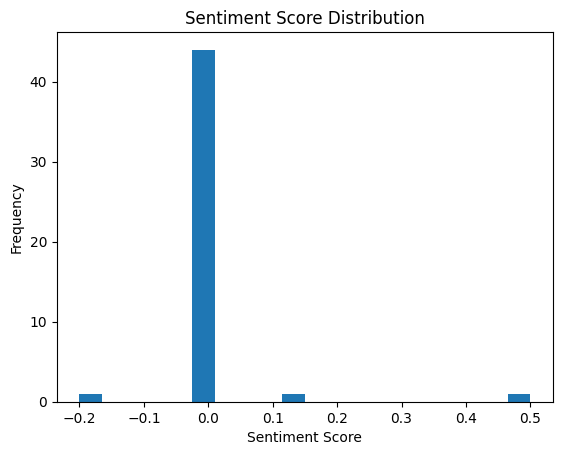

In [ ]:
df["sentiment"] = compute_sentiment(df["title"] + " " + df["text"])

print(df["sentiment"].describe())

df[["title", "source", "domain", "sentiment"]].head(20)

df["sentiment"].plot(
    kind="hist",
    bins=20,
    title="Sentiment Score Distribution",
    xlabel="Sentiment Score"
)

# Machine Learning Analysis

## Objective
The goal for the use of ML is to determine whether the text of the news articles has enough information to predict the source. We use the source as a proxy to determine regional differences in media coverage.

# Usage
We convert the cleaned text into a number using TFIDF. This makes sure to capture the importance of words in the article. We then used a regression model to classify articles based on their sources. This makes it so that the model can detect patterns in the text, when looking at different sources.

# Importance
This matters because if the model is able to predict the source using only the text, this means that different news outlets use distinct language patterns, which supports the idea that media framing varies across sources.


In [30]:
X, vectorizer = compute_tfidf(df["clean_text"])

In [31]:
df = df.dropna(subset=["source"])

y = df["source"]

In [32]:
model, acc = train_model(X, y)
print("Model Accuracy:", acc)

c:\Users\belde\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1201: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


ValueError: too many values to unpack (expected 2)

In [ ]:
baseline = baseline_model(y)
print("Baseline Accuracy:", baseline)

# Model Interpretation


The logistic regression model achieved an accuracy of 0.25, while the baseline accuracy was 0.50. This indicates that the model is not performing well and is unable to learn meaningful patterns from the data to predict the source of the articles.

One reason for this is that the dataset contains limited textual information, as it primarily uses article titles and timestamps rather than full article content. Additionally, the "source" field represents country information rather than specific news outlets, making the classification task more difficult.

These results suggest that while machine learning has potential for analyzing media framing, improvements in data quality and feature selection are needed for better performance.

# Reflection

The most difficult part of the project overall has been collecting data and turning it into a clean, consistent dataset for analysis. Because we are collecting articles from multiple sources, the source names, text fields, and labels do not always match, which is why preparation took longer than expected. 

Our idea that media framing can vary depending on the article's source is supported by one of our initial findings which is that there seem to be differences in tone and language between sources. Additionally, since we were able to clean the data, perform sentiment analysis, create a visualization, and test a machine learning model with a baseline for comparison, we now have some measurable results. 

However, one of our main issues at the moment is that the dataset is still tiny and uneven, which makes it more difficult to get good model performance. I think we are mostly on track because we already have a working pipeline and some initial findings. We still have to give more time to improving the dataset and improving the analysis, though. I do think the effort is justified based on what we have seen so far because the topic is important, the data shows some real patterns, and the results should become much more reliable with more data and clearer labels.


# Next Step

We will next collect more articles and improve the dataset to make the content and source information more accurate and consistent. We also hope to provide more accurate comparisons between sources by investigating differences in tone and wording.  We want to enhance machine learning results and increase the accuracy of the visualizations by using a larger and more balanced dataset.  We will know we are making progress if our model performs better than the baseline and our graphs show clearer patterns.